In [3]:
# 1. Prepare decision tree classifier in python using sklearn library for data set diabetes.csv - (pregnant, glucose, bp, skin, insulin, bmi, pedigree, age, label). Use all features except label as independent variable. Use complete dataset for training and limit the depth of tree upto 3 levels and plot using tree.plotTree()method.

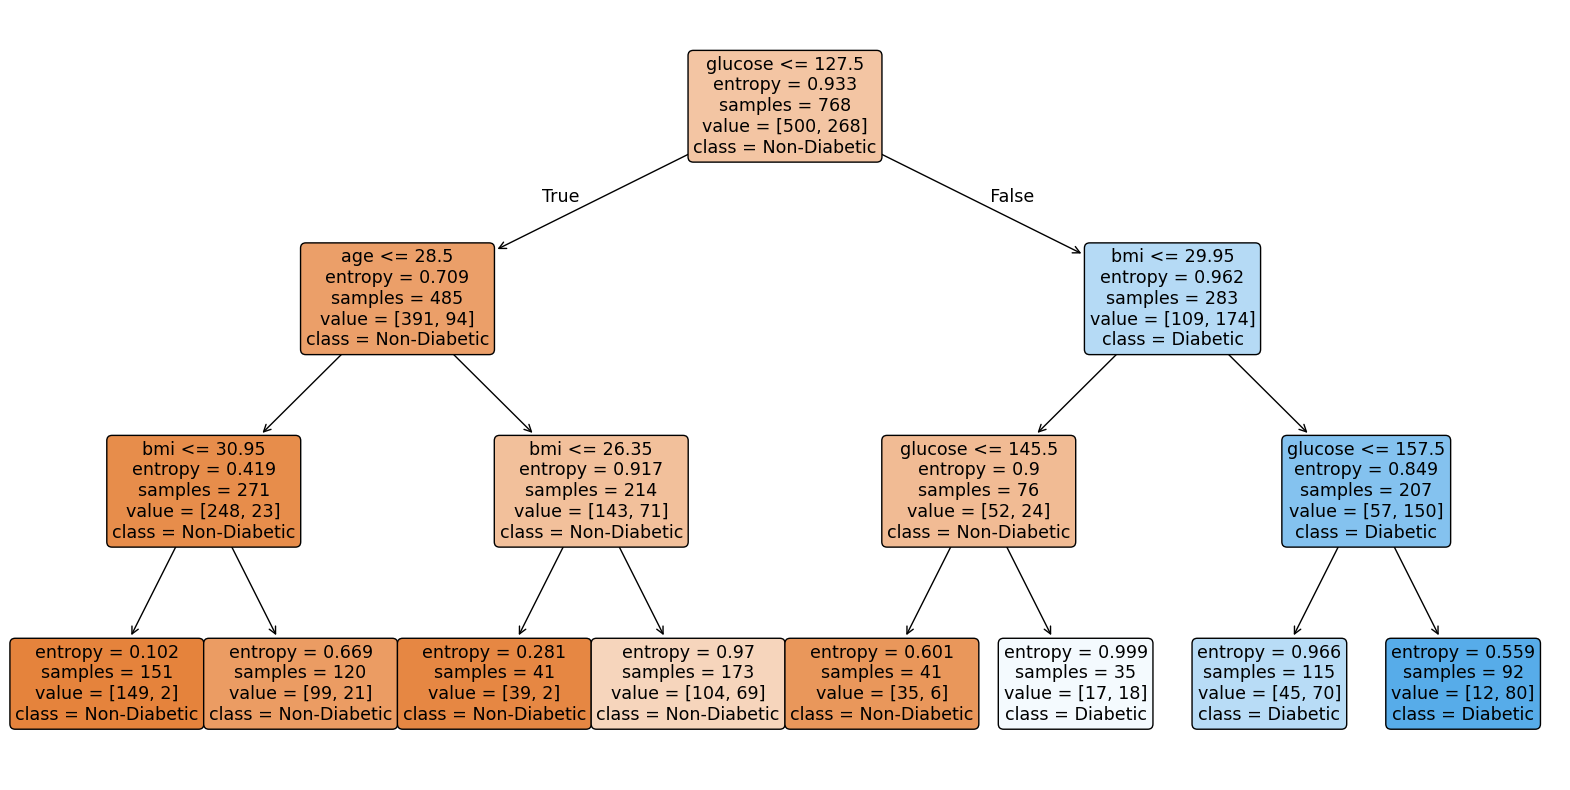

In [6]:
# Import required libraries

import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import matplotlib.pyplot as plt

# Load the dataset
# Note: We rename the columns to match the names specified in the instructions
data = pd.read_csv("diabetes.csv")
data.columns = ['pregnant', 'glucose', 'bp', 'skin', 'insulin', 'bmi', 'pedigree', 'age', 'label']

# Separate independent and dependent variables

X = data.drop("label", axis=1)
y = data["label"]

# Create and train the Decision Tree Classifier

clf = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    random_state=42
)

clf.fit(X, y)

# Plot the Decision Tree

plt.figure(figsize=(20, 10))
tree.plot_tree(
    clf,
    feature_names=X.columns,
    class_names=["Non-Diabetic", "Diabetic"],
    filled=True,
    rounded=True
)
plt.show()

In [7]:
# 2. Using the diabetes dataset, implement a Decision Tree Classifier and determine the importance of each feature in predicting diabetes. Generate different plots to justify your model.

    Feature  Importance
1   glucose    0.492488
5       bmi    0.271401
7       age    0.141969
2        bp    0.043612
4   insulin    0.026136
0  pregnant    0.024394
3      skin    0.000000
6  pedigree    0.000000


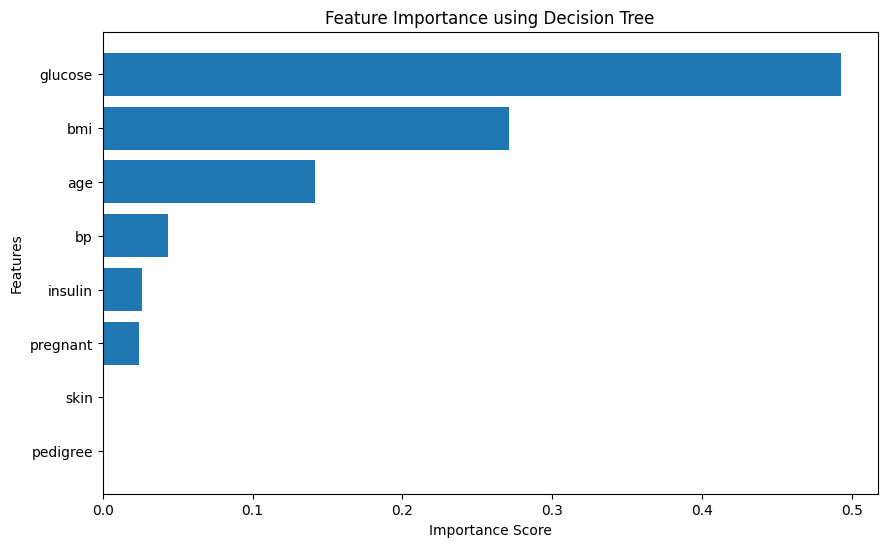

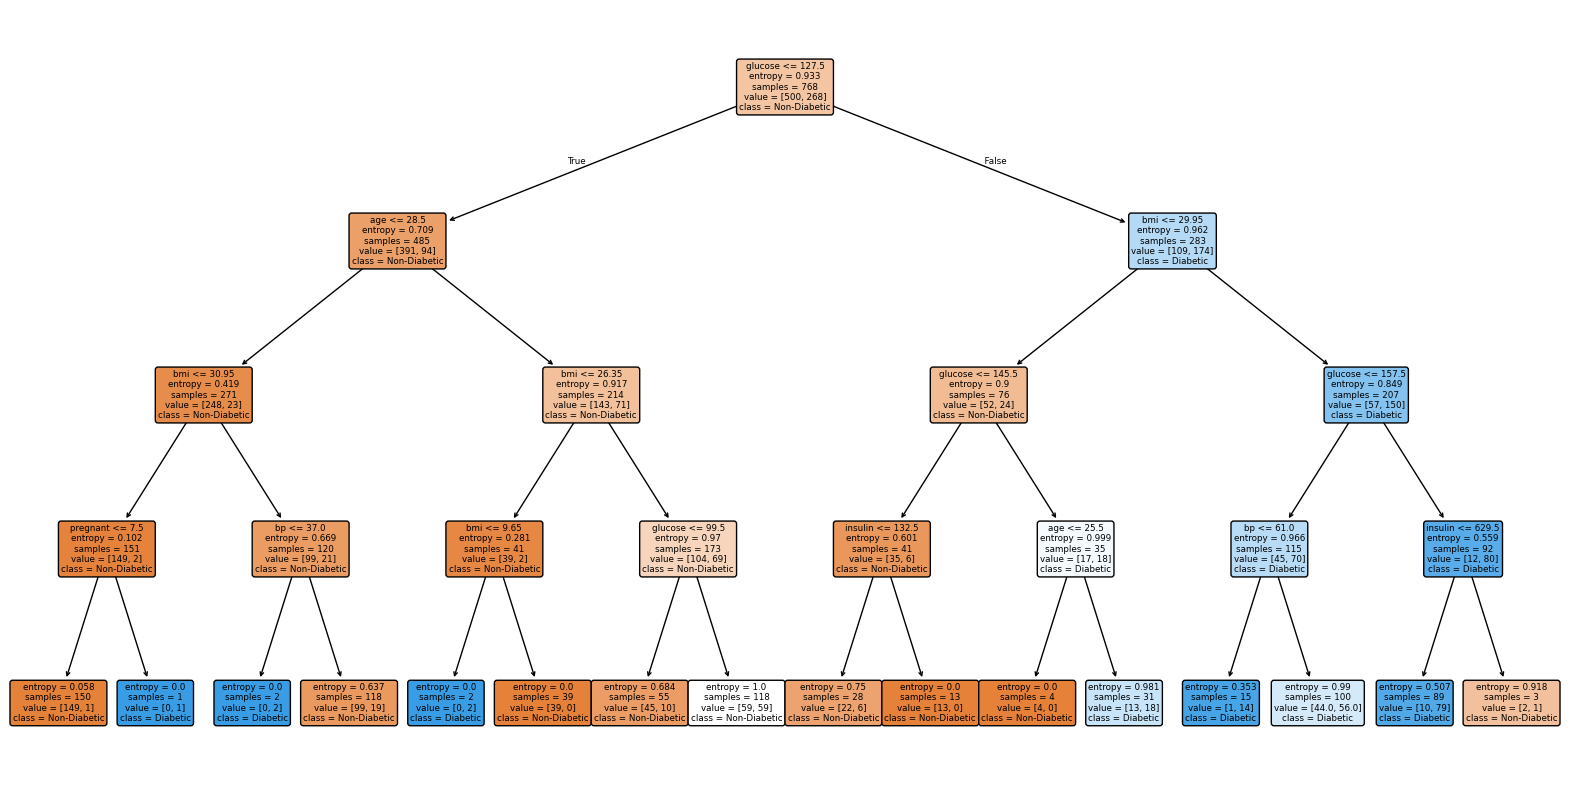

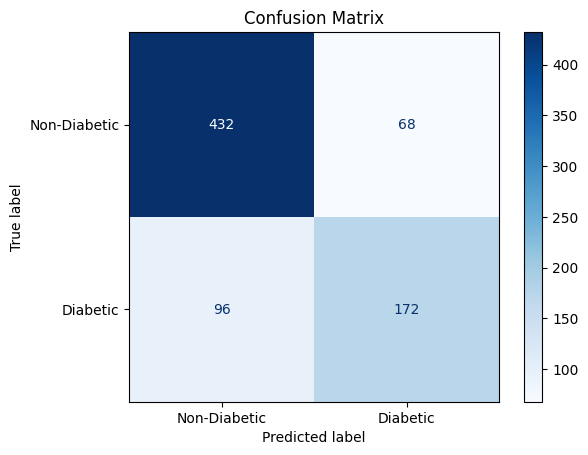

Model Accuracy: 0.7864583333333334


In [10]:
# Import required libraries

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Load the diabetes dataset

data = pd.read_csv("diabetes.csv")

# Rename columns to match the expected names
data.columns = ['pregnant', 'glucose', 'bp', 'skin', 'insulin', 'bmi', 'pedigree', 'age', 'label']

# Split features and target

X = data.drop("label", axis=1)
y = data["label"]

# Train Decision Tree Classifier

model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    random_state=42
)

model.fit(X, y)

# Feature Importance

importances = model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feature_importance_df)

# Plot 1: Feature Importance Bar Chart

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df["Feature"], feature_importance_df["Importance"])
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance using Decision Tree")
# Invert y-axis to show the most important features at the top
plt.gca().invert_yaxis()
plt.show()

# Plot 2: Decision Tree Visualization

plt.figure(figsize=(20, 10))
tree.plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Non-Diabetic", "Diabetic"],
    filled=True,
    rounded=True
)
plt.show()

# Plot 3: Confusion Matrix

y_pred = model.predict(X)

cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Diabetic", "Diabetic"])

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# Model Accuracy

accuracy = accuracy_score(y, y_pred)
print("Model Accuracy:", accuracy)

In [11]:
# 3. Implement a Decision Tree Classifier and compare its performance with a SVM Classifier on the iris dataset. Display the accuracy of both models.

In [13]:
# Import required libraries

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Load the Iris dataset

iris = load_iris()
X = iris.data
y = iris.target

# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train Decision Tree Classifier

dt_model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

# Train Support Vector Machine (SVM) Classifier

svm_model = SVC(kernel="linear", random_state=42)

svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_pred)

# Display Accuracy of Both Model

print("Decision Tree Accuracy:", dt_accuracy)
print("SVM Accuracy:", svm_accuracy)

Decision Tree Accuracy: 0.9777777777777777
SVM Accuracy: 1.0


In [14]:
# 4. Build decision tree classifier for iris data set. One with maximum leaf nodes up to 8 and another one with minimum sample per leaf as 5. Compare accuracy of both models.

In [15]:
# Import required libraries

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Load the Iris dataset

iris = load_iris()
X = iris.data
y = iris.target

# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Model 1: Decision Tree with max_leaf_nodes =

dt_max_leaf = DecisionTreeClassifier(
    max_leaf_nodes=8,
    random_state=42
)

dt_max_leaf.fit(X_train, y_train)
pred_leaf = dt_max_leaf.predict(X_test)

accuracy_leaf = accuracy_score(y_test, pred_leaf)

# Model 2: Decision Tree with min_samples_leaf = 5

dt_min_samples = DecisionTreeClassifier(
    min_samples_leaf=5,
    random_state=42
)

dt_min_samples.fit(X_train, y_train)
pred_samples = dt_min_samples.predict(X_test)

accuracy_samples = accuracy_score(y_test, pred_samples)

# Compare Accuracies

print("Accuracy with max_leaf_nodes = 8 :", accuracy_leaf)
print("Accuracy with min_samples_leaf = 5 :", accuracy_samples)

Accuracy with max_leaf_nodes = 8 : 1.0
Accuracy with min_samples_leaf = 5 : 1.0


In [16]:
# 5. Implement a Decision Tree Classifier and compare its performance with a
# Logistic Classifier on the diabetes dataset. Develop Python code to display the accuracy of both models.

In [18]:
# Import required libraries

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load the diabetes dataset

data = pd.read_csv("diabetes.csv")

# Rename columns to match the expected names used in the code
data.columns = ['pregnant', 'glucose', 'bp', 'skin', 'insulin', 'bmi', 'pedigree', 'age', 'label']

# Split features and target variable

X = data.drop("label", axis=1)
y = data["label"]

# Train–Test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Decision Tree Classifier

dt_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

# Logistic Regression Classifier

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)

log_accuracy = accuracy_score(y_test, log_pred)

# Display accuracy of both models

print("Decision Tree Accuracy:", dt_accuracy)
print("Logistic Regression Accuracy:", log_accuracy)

Decision Tree Accuracy: 0.7748917748917749
Logistic Regression Accuracy: 0.7359307359307359


In [19]:
# 6. Develop a random dataset using 3 columns and 350 rows. Generate the data frame and apply decision tree classifier to train the model. Compare the accuracy of the model with any 2 other models you can apply on the generated dataset. Generate plot of comparing the accuracy for different models.

   Feature1  Feature2  Feature3  Target
0  0.374540  0.950714  0.731994       0
1  0.598658  0.156019  0.155995       0
2  0.058084  0.866176  0.601115       0
3  0.708073  0.020584  0.969910       1
4  0.832443  0.212339  0.181825       1
Decision Tree Accuracy : 0.5714285714285714
Logistic Regression Accuracy : 0.5333333333333333
KNN Accuracy : 0.5904761904761905


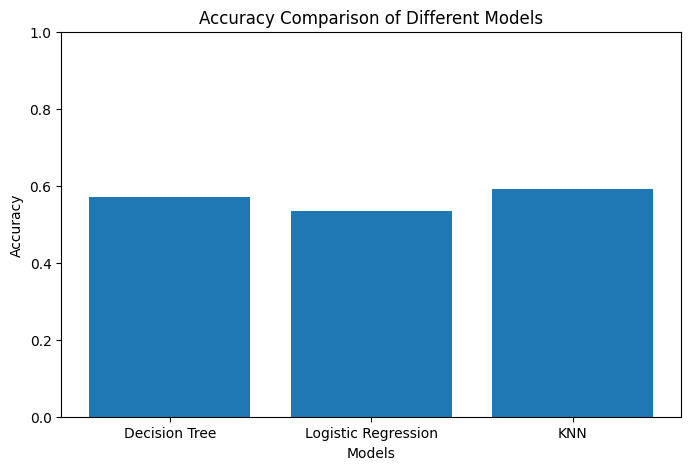

In [22]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Generate a random dataset (3 columns, 350 rows)
np.random.seed(42)

X = np.random.rand(350, 3)   # 3 feature columns
y = np.random.randint(0, 2, 350)  # binary target (0 or 1)

# Create DataFrame
data = pd.DataFrame(X, columns=["Feature1", "Feature2", "Feature3"])
data["Target"] = y

print(data.head())

# Split dataset into training and testing sets

X = data.drop("Target", axis=1)
y = data["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Model 1: Decision Tree Classifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_pred)

# Model 2: Logistic Regression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_pred)

# Model 3: K-Nearest Neighbors (KNN)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)
knn_accuracy = accuracy_score(y_test, knn_pred)

# Display accuracy of all models

print("Decision Tree Accuracy :", dt_accuracy)
print("Logistic Regression Accuracy :", lr_accuracy)
print("KNN Accuracy :", knn_accuracy)


# Plot accuracy comparison of models

models = ["Decision Tree", "Logistic Regression", "KNN"]
accuracies = [dt_accuracy, lr_accuracy, knn_accuracy]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison of Different Models")
plt.ylim(0, 1)
plt.show()

In [23]:
# 7. Using the diabetes dataset, implement a Decision Tree Classifier and plot ccp_alpha of built tree against any one DT parameter (node count or maximum depth). please add comments for reading and understanding

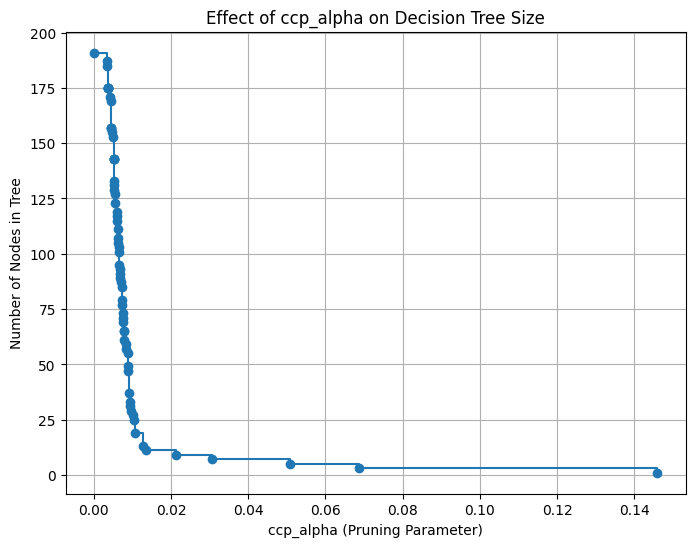

In [25]:
# Import required libraries

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

# Load the diabetes dataset

# Load dataset
data = pd.read_csv("diabetes.csv")

# Rename columns to match the expected names
data.columns = ['pregnant', 'glucose', 'bp', 'skin', 'insulin', 'bmi', 'pedigree', 'age', 'label']

# Separate features and target
X = data.drop("label", axis=1)
y = data["label"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Create a full decision tree
dt = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

dt.fit(X_train, y_train)

# Obtain pruning path
path = dt.cost_complexity_pruning_path(X_train, y_train)

ccp_alphas = path.ccp_alphas       # effective alphas
impurities = path.impurities       # corresponding impurities

node_counts = []

# Train a tree for each alpha and store number of nodes
for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(
        criterion="entropy",
        random_state=42,
        ccp_alpha=alpha
    )
    clf.fit(X_train, y_train)
    node_counts.append(clf.tree_.node_count)

# Plot: ccp_alpha vs Number of Nodes

plt.figure(figsize=(8, 6))

plt.plot(ccp_alphas, node_counts, marker='o', drawstyle="steps-post")

plt.xlabel("ccp_alpha (Pruning Parameter)")
plt.ylabel("Number of Nodes in Tree")
plt.title("Effect of ccp_alpha on Decision Tree Size")
plt.grid(True)

plt.show()

In [26]:
# 23. Write a Python code to perform Leave-One-Out Cross-Validation (LOOCV) on a dataset using a Decision Tree Classifier. The dataset consists of features and labels as specified below. Dataset Description: • The dataset consists of 100 samples with 5 features. • The target variable is binary (0 or 1). Instructions: Import the necessary libraries. • Load or create a synthetic dataset with the specified characteristics. • Implement Leave-One-Out Cross-Validation (LOOCV). • Train a Decision Tree Classifier on each training set and evaluate it on the left-out sample. Print the accuracy for each iteration and the average accuracy across all iterations.

In [27]:
# 1. Import necessary libraries
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score

# 2. Create a synthetic dataset
# 100 samples, 5 features
np.random.seed(42)   # For reproducibility

X = np.random.rand(100, 5)           # Feature matrix
y = np.random.randint(0, 2, 100)     # Binary target labels (0 or 1)

# 3. Initialize Leave-One-Out Cross-Validation
loo = LeaveOneOut()

# Create Decision Tree Classifier
model = DecisionTreeClassifier(random_state=42)
# 4. Perform LOOCV
accuracies = []   # To store accuracy of each iteration
iteration = 1

for train_index, test_index in loo.split(X):

    # Split data into training and test sets
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Train the model
    model.fit(X_train, y_train)

    # Predict on the left-out sample
    y_pred = model.predict(X_test)

    # Calculate accuracy for this iteration
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    # Print accuracy for this iteration
    print(f"Iteration {iteration}: Accuracy = {acc}")
    iteration += 1

# 5. Calculate and print average accuracy
average_accuracy = np.mean(accuracies)
print("\nAverage LOOCV Accuracy:", average_accuracy)


Iteration 1: Accuracy = 0.0
Iteration 2: Accuracy = 0.0
Iteration 3: Accuracy = 0.0
Iteration 4: Accuracy = 0.0
Iteration 5: Accuracy = 0.0
Iteration 6: Accuracy = 1.0
Iteration 7: Accuracy = 0.0
Iteration 8: Accuracy = 0.0
Iteration 9: Accuracy = 0.0
Iteration 10: Accuracy = 0.0
Iteration 11: Accuracy = 1.0
Iteration 12: Accuracy = 0.0
Iteration 13: Accuracy = 0.0
Iteration 14: Accuracy = 1.0
Iteration 15: Accuracy = 1.0
Iteration 16: Accuracy = 1.0
Iteration 17: Accuracy = 1.0
Iteration 18: Accuracy = 0.0
Iteration 19: Accuracy = 1.0
Iteration 20: Accuracy = 0.0
Iteration 21: Accuracy = 1.0
Iteration 22: Accuracy = 0.0
Iteration 23: Accuracy = 1.0
Iteration 24: Accuracy = 1.0
Iteration 25: Accuracy = 1.0
Iteration 26: Accuracy = 0.0
Iteration 27: Accuracy = 0.0
Iteration 28: Accuracy = 0.0
Iteration 29: Accuracy = 1.0
Iteration 30: Accuracy = 1.0
Iteration 31: Accuracy = 1.0
Iteration 32: Accuracy = 0.0
Iteration 33: Accuracy = 1.0
Iteration 34: Accuracy = 1.0
Iteration 35: Accuracy 

In [28]:
# 24. Write a Python code to perform Leave-One-Out Cross-Validation (LOOCV) on a dataset using a Decision Tree Classifier. The dataset consists of features and labels as specified below. Dataset Description: • The dataset consists of 150 samples with 10 features. • The target variable is categorical with three classes (0, 1, 2). • Introduce some noise to the dataset to make the classification task more Instructions: • Import the necessary libraries. • Load or create a synthetic dataset with the specified characteristics (make_classification), including noise. • Implement Leave-One-Out Cross-Validation (LOOCV). • Train a Decision Tree Classifier on each training set and evaluate it on the left-out sample. • Calculate and print the accuracy for each iteration, as well as the confusion matrix for the final model. • Calculate and print the average accuracy across all iterations. Print confusion matrix and classificarion report.

In [29]:
# 1. Import necessary libraries
import numpy as np
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 2. Create a synthetic dataset with noise
# 150 samples, 10 features, 3 classes
# flip_y introduces label noise
X, y = make_classification(
    n_samples=150,
    n_features=10,
    n_informative=7,
    n_redundant=2,
    n_classes=3,
    flip_y=0.15,          # noise in labels
    class_sep=1.0,
    random_state=42
)

# 3. Initialize Leave-One-Out Cross-Validation
loo = LeaveOneOut()

# Initialize Decision Tree Classifier
dt_model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

# 4. Perform LOOCV
accuracies = []     # To store accuracy of each iteration
iteration = 1

for train_index, test_index in loo.split(X):

    # Split the dataset
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Train the model
    dt_model.fit(X_train, y_train)

    # Predict the left-out sample
    y_pred = dt_model.predict(X_test)

    # Accuracy for this iteration (0 or 1)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    print(f"Iteration {iteration}: Accuracy = {acc}")
    iteration += 1

# 5. Calculate and print average accuracy
average_accuracy = np.mean(accuracies)
print("\nAverage LOOCV Accuracy:", average_accuracy)


Iteration 1: Accuracy = 1.0
Iteration 2: Accuracy = 0.0
Iteration 3: Accuracy = 0.0
Iteration 4: Accuracy = 0.0
Iteration 5: Accuracy = 0.0
Iteration 6: Accuracy = 0.0
Iteration 7: Accuracy = 0.0
Iteration 8: Accuracy = 0.0
Iteration 9: Accuracy = 1.0
Iteration 10: Accuracy = 1.0
Iteration 11: Accuracy = 1.0
Iteration 12: Accuracy = 0.0
Iteration 13: Accuracy = 0.0
Iteration 14: Accuracy = 0.0
Iteration 15: Accuracy = 1.0
Iteration 16: Accuracy = 0.0
Iteration 17: Accuracy = 0.0
Iteration 18: Accuracy = 1.0
Iteration 19: Accuracy = 1.0
Iteration 20: Accuracy = 1.0
Iteration 21: Accuracy = 1.0
Iteration 22: Accuracy = 1.0
Iteration 23: Accuracy = 1.0
Iteration 24: Accuracy = 0.0
Iteration 25: Accuracy = 1.0
Iteration 26: Accuracy = 1.0
Iteration 27: Accuracy = 1.0
Iteration 28: Accuracy = 1.0
Iteration 29: Accuracy = 1.0
Iteration 30: Accuracy = 0.0
Iteration 31: Accuracy = 0.0
Iteration 32: Accuracy = 1.0
Iteration 33: Accuracy = 1.0
Iteration 34: Accuracy = 0.0
Iteration 35: Accuracy 